<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN-WK9.B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Simulating Progressive Growing Stages...


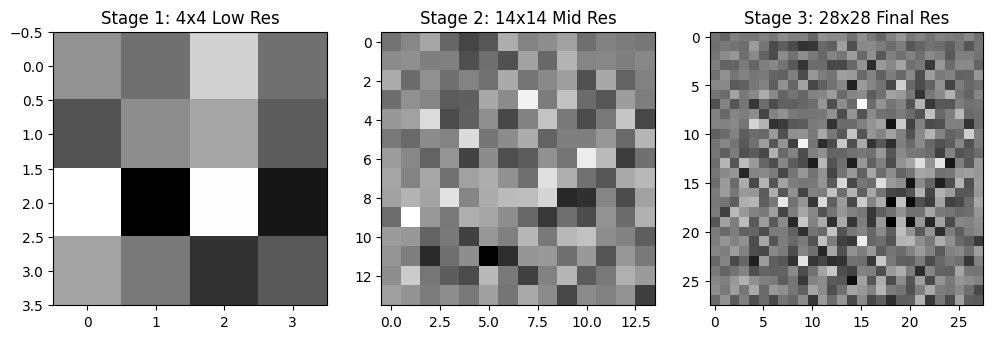

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load Data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5  # Normalize to [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)

# 2. Simplified Standard GAN (Fixed 28x28 resolution)
def build_generator():
    model = models.Sequential([
        layers.Dense(7*7*256, input_dim=100),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ])
    return model

# 3. Demonstration of "Progressive Growing" Logic
# In a real ProGAN, we add layers. Here, we simulate the output at different stages.
def show_progressive_growth(generator, noise):
    generated_img = generator(noise, training=False)

    plt.figure(figsize=(12, 4))

    # Stage 1: Low Res (4x4)
    plt.subplot(1, 3, 1)
    low_res = tf.image.resize(generated_img, [4, 4])
    plt.imshow(low_res[0, :, :, 0], cmap='gray')
    plt.title("Stage 1: 4x4 Low Res")

    # Stage 2: Mid Res (14x14)
    plt.subplot(1, 3, 2)
    mid_res = tf.image.resize(generated_img, [14, 14])
    plt.imshow(mid_res[0, :, :, 0], cmap='gray')
    plt.title("Stage 2: 14x14 Mid Res")

    # Stage 3: High Res (28x28)
    plt.subplot(1, 3, 3)
    plt.imshow(generated_img[0, :, :, 0], cmap='gray')
    plt.title("Stage 3: 28x28 Final Res")

    plt.show()

# Initialize and Test
generator = build_generator()
noise = tf.random.normal([1, 100])
print("Simulating Progressive Growing Stages...")
show_progressive_growth(generator, noise)